In [26]:
import pickle
import glob
import numpy as np


a_dir = '../runs/end_to_end/reprover-v1-novel-no-split-2/2024_05_22/15_07_08/traces/0/'
a_files = glob.glob(a_dir + '*')

b_dir = '../runs/cluster_runs_no_split/0/'

b_files = glob.glob(b_dir + '*')

a_thms = [f.split('/')[-1] for f in a_files]
both_files = [f for f in b_files if f.split('/')[-1] in a_thms]


In [35]:
for file in both_files:
    try:
        trace_b = pickle.load(open(file, 'rb'))
        trace_a = pickle.load(open([file_a for file_a in a_files if file_a.split('/')[-1] in file.split('/')[-1]][0], 'rb'))
        
        if trace_a.proof and not trace_b.proof:
            break
    except:
        pass

In [36]:
trace_a

SearchResult(theorem=Theorem(repo=LeanGitRepo(url='https://github.com/leanprover-community/mathlib', commit='8c1b484d6a214e059531e22f1be9898ed6c1fd47'), file_path=PosixPath('src/analysis/inner_product_space/pi_L2.lean'), full_name='orthonormal_basis.span_apply'), status=<Status.PROVED: 'Proved'>, proof=["letI := <a>classical.dec_eq</a> ι'", 'rw <a>orthonormal_basis.span</a>', 'simp [<a>basis.span</a>]'], tree=InternalNode(goal="ι' : Type u_2,\n𝕜 : Type u_3,\n_inst_1 : is_R_or_C 𝕜,\nE : Type u_4,\n_inst_2 : normed_add_comm_group E,\n_inst_3 : inner_product_space 𝕜 E,\n_inst_11 : decidable_eq E,\nv' : ι' → E,\nh : orthonormal 𝕜 v',\ns : finset ι',\ni : ↥s\n⊢ ↑(⇑(orthonormal_basis.span h s) i) = v' ↑i", _status=<Status.PROVED: 'Proved'>), total_time=149.73337794299005, tac_time=16.9754418170196, search_time=0.00026451502344571054, env_time=132.75629955210024, num_expansions=512, num_nodes=31)

In [37]:
trace_b

SearchResult(theorem=Theorem(repo=LeanGitRepo(url='https://github.com/leanprover-community/mathlib', commit='8c1b484d6a214e059531e22f1be9898ed6c1fd47'), file_path=PosixPath('src/analysis/inner_product_space/pi_L2.lean'), full_name='orthonormal_basis.span_apply'), status=<Status.OPEN: 'Open'>, proof=None, tree=InternalNode(goal="ι' : Type u_2,\n𝕜 : Type u_3,\n_inst_1 : is_R_or_C 𝕜,\nE : Type u_4,\n_inst_2 : normed_add_comm_group E,\n_inst_3 : inner_product_space 𝕜 E,\n_inst_11 : decidable_eq E,\nv' : ι' → E,\nh : orthonormal 𝕜 v',\ns : finset ι',\ni : ↥s\n⊢ ↑(⇑(orthonormal_basis.span h s) i) = v' ↑i", _status=<Status.OPEN: 'Open'>), total_time=737.9269526280113, tac_time=118.91767286788672, search_time=0.0027762859244830906, env_time=618.9987451148918, num_expansions=1344, num_nodes=75)

In [40]:
tac_a = [t.tactic for t in trace_a.tree.out_edges]
tac_b = [t.tactic for t in trace_b.tree.out_edges]

In [52]:
node_2_b = [e for e in trace_b.tree.out_edges if e.tactic == trace_a.proof[0]][0]
node_2_a = [e for e in trace_a.tree.out_edges if e.tactic == trace_a.proof[0]][0]

In [55]:
node_2_a

Edge(tactic="letI := <a>classical.dec_eq</a> ι'", tac_logprob=-5.604743003845215, goal_logprob=0.0, time=0.19373406301019713)

In [58]:
node_2_b.dst

[InternalNode(goal="ι' : Type u_2,\n𝕜 : Type u_3,\n_inst_1 : is_R_or_C 𝕜,\nE : Type u_4,\n_inst_2 : normed_add_comm_group E,\n_inst_3 : inner_product_space 𝕜 E,\n_inst_11 : decidable_eq E,\nv' : ι' → E,\nh : orthonormal 𝕜 v',\ns : finset ι',\ni : ↥s,\n_inst : decidable_eq ι' := classical.dec_eq ι'\n⊢ ↑(⇑(orthonormal_basis.span h s) i) = v' ↑i", _status=<Status.OPEN: 'Open'>)]

In [59]:
tac_a = [t.tactic for t in node_2_a.dst[0].out_edges]
tac_b = [t.tactic for t in node_2_b.dst[0].out_edges]


In [61]:
node_2_a = [e for e in node_2_a.dst[0].out_edges if e.tactic == trace_a.proof[1]][0]
node_2_b = [e for e in node_2_b.dst[0].out_edges if e.tactic == trace_a.proof[1]][0]

In [66]:
[t for t in node_2_a.dst[0].out_edges if t.tactic == trace_a.proof[2]][0].dst

[ProofFinishedNode(inner=GoalFinished(message=None))]

In [67]:
[t for t in node_2_b.dst[0].out_edges if t.tactic == trace_a.proof[2]][0].dst

[ErrorNode(inner=EnvironmentError(message='gen_tac_and_capture_res_failed: pos=none msg="try_for_time tactic failed, timeout" tactic_state="ι\' : Type u_2,\n𝕜 : Type u_3,\n_inst_1 : is_R_or_C 𝕜,\nE : Type u_4,\n_inst_2 : normed_add_comm_group E,\n_inst_3 : inner_product_space 𝕜 E,\n_inst_11 : decidable_eq E,\nv\' : ι\' → E,\nh : orthonormal 𝕜 v\',\ns : finset ι\',\ni : ↥s,\n_inst : decidable_eq ι\' := classical.dec_eq ι\'\n⊢ ↑(⇑(let e₀\' : basis ↥s 𝕜 ↥(submodule.span 𝕜 (range (v\' ∘ coe))) := basis.span _,\n              e₀ : orthonormal_basis ↥s 𝕜 ↥(submodule.span 𝕜 (range (v\' ∘ coe))) :=\n                orthonormal_basis.mk _ _,\n              φ : ↥(submodule.span 𝕜 ↑(finset.image v\' s)) ≃ₗᵢ[𝕜]\n                ↥(submodule.span 𝕜 (range (v\' ∘ coe))) :=\n                linear_isometry_equiv.of_eq (submodule.span 𝕜 ↑(finset.image v\' s))\n                  (submodule.span 𝕜 (range (v\' ∘ coe)))\n                  _\n          in e₀.map φ.symm)\n         i) =\n    v\' ↑i"'))]

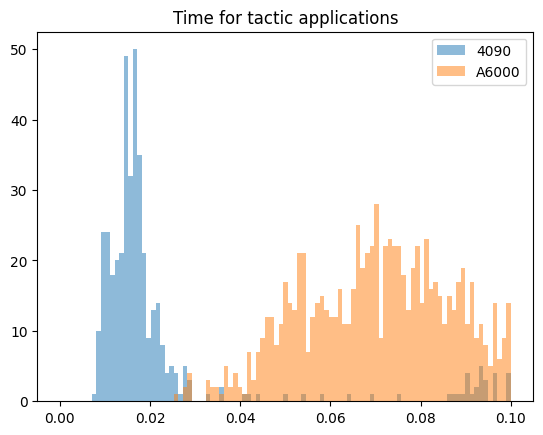

In [68]:
a_times = [t.time for t in trace_a.trace]
b_times = [t.time for t in trace_b.trace]
import matplotlib.pyplot as plt

# histogram of a times and b times overlayed on the same figure with legend
bins = np.linspace(0, 0.1, 100)


plt.hist(a_times, bins, alpha=0.5, label='4090')
plt.hist(b_times, bins, alpha=0.5, label='A6000')
plt.legend(loc='upper right')
plt.title('Time for tactic applications')
plt.show()

